<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# BSM Analysis — Majorana Neutrinos: Framework Verification and Consistency Tests
---
This notebook validates the **Majorana-neutrino** extension implemented in tpeanuts:
`PMNS_Majorana` (`core/BSM/bsm_majorana.py`), its integration with the shared Hamiltonian
builders and evolutors, and the one observable that genuinely distinguishes Majorana from
Dirac neutrinos, the effective Majorana mass $m_{\beta\beta}$.

The central physical claim under test is a **theorem, not an approximation**: the two extra
Majorana CP phases $\alpha_{21},\alpha_{31}$ have *no effect whatsoever* on any oscillation
probability computed by this project, at any level (PMNS matrix relation, Hamiltonian,
full L/E probability scan). `PMNS_Majorana` is therefore a drop-in replacement for `PMNS_SM`
everywhere propagation is concerned — this notebook verifies that claim numerically, then
shows the one place ($m_{\beta\beta}$) where the phases genuinely do matter.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Configuration-Analysis--Mixing-Matrix-Structure) | **Configuration Analysis — Mixing Matrix Structure** |
| [4](#4.-Majorana-Phase-Invariance-Verification) | **Majorana-Phase Invariance Verification** |
| [5](#5.-Unitarity-and-Probability-Conservation) | **Unitarity and Probability Conservation** |
| [6](#6.-Hamiltonian-Structure) | **Hamiltonian Structure** |
| [7](#7.-Effective-Majorana-Mass-m_betabeta) | **Effective Majorana Mass ($m_{\beta\beta}$)** |
| [8](#8.-Summary) | **Summary** |


## 0. Theoretical Framework




### 0.1 Dirac versus Majorana Neutrinos

A **Dirac** neutrino is distinct from its antiparticle, like every other Standard Model
fermion; a **Majorana** neutrino is its own antiparticle, which requires lepton number to
be violated somewhere in the theory. Whether neutrinos are Dirac or Majorana is itself a
BSM question — the Standard Model has no right-handed neutrino field and no
lepton-number-violating mass term at all — which is why this extension lives in
`core.BSM`, alongside NSI and the 3+1 sterile scheme, rather than in `core.SM`.

For $n$ generations the number of physical CP-violating phases in the leptonic mixing
matrix is $n(n-1)/2$ if neutrinos are Majorana particles, versus only $(n-1)(n-2)/2$ if
they are Dirac particles. For $n=3$ this is $3$ Majorana-case phases versus $1$
Dirac-case phase: the familiar CP phase $\delta$ survives in both cases, and two
**additional physical phases** $\alpha_{21},\alpha_{31}$ appear only if neutrinos are
Majorana particles.

---


### 0.2 The `PMNS_Majorana` Matrix

`PMNS_Majorana` is a *sibling* of `PMNS_SM` (both direct `PMNS` subclasses — exactly how
`PMNS_sterile` sits alongside `PMNS_SM` rather than inheriting from it), reusing the shared
generators $R_{12}, R_{13}, R_{23}, \Delta$ unchanged and building:

$$U = R_{23}\,\Delta\,R_{13}\,\Delta^\dagger\,R_{12}\,P,
\qquad U_{\rm red} = R_{13}\,R_{12}\,P,$$

with

$$P = {\rm diag}\!\left(1,\; e^{i\alpha_{21}/2},\; e^{i\alpha_{31}/2}\right)$$

built from the companion `MajoranaPhases` parameter object (mirroring
`PMNSSterileParams`), and reusing the already-generic `PMNS._phase_diag` builder that also
constructs $\Delta$ — no change to `core.common` was needed. The outer block
$O=R_{23}\,\Delta$ is *identical* to the plain SM case: the Majorana phase lives entirely
on the mass-eigenstate (right-hand) side of the factorisation $U=O\,U_{\rm red}$, so it
never touches the matter-Hamiltonian structure.

---


### 0.3 Rephasing Invariance of Oscillation Probabilities

The vacuum oscillation amplitude is $A(\nu_\alpha\to\nu_\beta)=\sum_i U_{\beta i}\,U_{\alpha
i}^*\,e^{-ik_ix}$. Writing $U=U_{\rm Dirac}\,P$, the contribution of mass eigenstate $i$
picks up the extra factor $P_{ii}$ from $U_{\beta i}$ and $P_{ii}^*$ from $U_{\alpha i}^*$,
which **cancel exactly** since $P_{ii}$ is a pure phase ($|P_{ii}|=1$):

$$U_{\beta i}\,U_{\alpha i}^* = \left(U_{\rm Dirac}\right)_{\beta i} P_{ii}\,
\left(U_{\rm Dirac}\right)_{\alpha i}^* P_{ii}^*
= \left(U_{\rm Dirac}\right)_{\beta i}\left(U_{\rm Dirac}\right)_{\alpha i}^*.$$

This holds term by term, for *every* $i$, independent of $k_i$ (hence of $E$, $L$, or the
mass ordering), of the matter profile, and of the propagation method. The same argument
applies one level down, at the Hamiltonian itself: since $P$ is diagonal it commutes with
the diagonal kinetic-eigenvalue matrix, so

$$U_{\rm red}\,{\rm diag}(k)\,U_{\rm red}^\dagger
= U_{\rm red}^{\rm Dirac}\,P\,{\rm diag}(k)\,P^\dagger\,{U_{\rm red}^{\rm Dirac}}^\dagger
= U_{\rm red}^{\rm Dirac}\,{\rm diag}(k)\,{U_{\rm red}^{\rm Dirac}}^\dagger$$

identically, for *any* $\alpha_{21},\alpha_{31}$. Sections 4-6 below verify both statements
numerically.

---


### 0.4 The One Observable That Does Depend on the Phases

The effective Majorana mass governing neutrinoless double-beta decay ($0\nu\beta\beta$) is

$$m_{\beta\beta} = \left|\sum_i U_{ei}^2\,m_i\right|.$$

Unlike an oscillation amplitude, this is **quadratic** (not linear) in the electron row of
$U$, so the Majorana phases do *not* cancel here — the standard counter-example to the
rephasing-invariance argument above. It is a zero-baseline, purely algebraic quantity: no
dependence on $L$, $E$, a matter profile, or a propagation method, and it requires the
*absolute* neutrino mass scale rather than only the mass-squared splittings this project
otherwise ever needs. Section 7 below computes it via
`core.BSM.bsm_majorana.effective_majorana_mass` and
`MassSpectrum.absolute_mass_squared_vector`, and explicitly contrasts its phase-dependence
against the invariance of Section 4.

**References**

- [1] Schechter, J., & Valle, J. W. F. (1982). Neutrinoless double-beta decay in SU(2) x U(1) theories. *Phys. Rev. D* **25**, 2951.
- [2] Bilenky, S. M., & Giunti, C. (2015). Neutrinoless double-beta decay: a probe of physics beyond the Standard Model. *Int. J. Mod. Phys. A* **30**, 1530001, [arXiv:1411.4791](https://arxiv.org/abs/1411.4791).
- [3] Giunti, C., & Kim, C. W. (2007). *Fundamentals of Neutrino Physics and Astrophysics*. Oxford.
- [4] GERDA Collaboration (2020). *Phys. Rev. Lett.* **125**, 252502, [arXiv:2009.06079](https://arxiv.org/abs/2009.06079).
- [5] KamLAND-Zen Collaboration (2023). [arXiv:2203.02139](https://arxiv.org/abs/2203.02139).
- [6] NuFIT 5.2 (2022). http://www.nu-fit.org.


## 1. Libraries




In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.hamiltonian import hamiltonian_reduced, hamiltonian_flavour, hamiltonian_matter_reduced
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.util.context import RuntimeContext

print(f"torch {torch.__version__}")
from tpeanuts.core.BSM.bsm_majorana import MajoranaPhases, PMNS_Majorana, effective_majorana_mass
from tpeanuts.core.SM.sm_pmns import PMNS_SM
from tpeanuts.core.common.pmns import PMNSParams
from tpeanuts.medium.vacuum.probability import vacuum_probability_transition


torch 2.5.1


## 2. Paths and Configuration




### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared
matplotlib/torch/numpy style, and creates the output directory.


In [2]:
# CPU is forced here: this environment's CUDA nvrtc JIT (complex128 kernels)
# is broken independently of tpeanuts; the physics verified below does not
# depend on device (see core.common.pmns docstrings).
config     = load_notebook_config(device="cpu")
context    = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "bsm")

print(f"Package dir : {config.package_dir}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {context.device}   dtype: {context.dtype}")


Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\bsm
Device      : cpu   dtype: torch.float64


### 2.2 Configuration

The Dirac baseline (`neutrino_nature="dirac"`, the default) is compared against three
illustrative Majorana-phase configurations, built directly through
`PropagationConfig.oscillation_parameters_from_preset(neutrino_nature="majorana", ...)`.
The angles themselves are unconstrained by oscillation data (that is precisely the point
of Section 4), so the three configurations below are chosen only to span a representative
range, not to reproduce any particular fit or benchmark.

| Configuration | $\alpha_{21}$ | $\alpha_{31}$ |
|---------------|--------------:|--------------:|
| `Dirac` | n/a | n/a |
| `Majorana A` | $45°$ | $90°$ |
| `Majorana B` | $180°$ | $0°$ |
| `Majorana C` | $0°$ | $270°$ |


In [3]:
MAJORANA_CONFIGS = [
    {"label": "Majorana A", "alpha21_deg": 45.0,  "alpha31_deg": 90.0,  "color": "firebrick"},
    {"label": "Majorana B", "alpha21_deg": 180.0, "alpha31_deg": 0.0,   "color": "darkorange"},
    {"label": "Majorana C", "alpha21_deg": 0.0,   "alpha31_deg": 270.0, "color": "seagreen"},
]

osc_dirac = PropagationConfig.oscillation_parameters_from_preset(
    "_SM_NUFIT52_NO", context=context,
)
oscs = {"Dirac": osc_dirac}
for cfg in MAJORANA_CONFIGS:
    oscs[cfg["label"]] = PropagationConfig.oscillation_parameters_from_preset(
        "_SM_NUFIT52_NO", context=context, neutrino_nature="majorana",
        alpha21_deg=cfg["alpha21_deg"], alpha31_deg=cfg["alpha31_deg"],
    )

ALL_LABELS = ["Dirac"] + [c["label"] for c in MAJORANA_CONFIGS]
ALL_COLORS = ["dimgray"] + [c["color"] for c in MAJORANA_CONFIGS]

rows = []
for label in ALL_LABELS:
    osc = oscs[label]
    rows.append({
        "configuration": label,
        "BSM_extension_majorana": osc.BSM_extension_majorana,
        "pmns class": type(osc.pmns).__name__,
    })
print(pd.DataFrame(rows).set_index("configuration").to_string())


               BSM_extension_majorana     pmns class
configuration                                       
Dirac                           False        PMNS_SM
Majorana A                       True  PMNS_Majorana
Majorana B                       True  PMNS_Majorana
Majorana C                       True  PMNS_Majorana


### 2.3 Local Helpers




In [4]:
def frobenius(A, B):
    """Frobenius norm ||A - B||_F."""
    diff = A - B
    return float(torch.sqrt((diff.abs() ** 2).sum()))


def max_diff(A, B):
    """Max absolute element-wise difference."""
    return float((A - B).abs().max())


## 3. Configuration Analysis — Mixing Matrix Structure

The $3\times3$ matrix $|U_{\alpha i}|^2$ (rows = flavour $\alpha\in\{e,\mu,\tau\}$, columns
= mass state $i\in\{1,2,3\}$) encodes how each flavour couples to each mass eigenstate.
Since $P$ is a pure phase matrix, $|U_{\alpha i}|=|(U_{\rm Dirac})_{\alpha i}|$ **exactly**
— the heatmaps below must be pixel-identical across all four configurations. What *does*
change is the complex argument of the entries in mass columns 2 and 3, shown in the table
underneath.

**Expected results:**<br>
- $|U_{\alpha i}|^2$ heatmaps identical to floating-point precision across all four configurations.
- $\arg(U_{e2})$ shifts by exactly $\alpha_{21}/2$ and $\arg(U_{e3})$ by exactly $\alpha_{31}/2$ relative to Dirac.


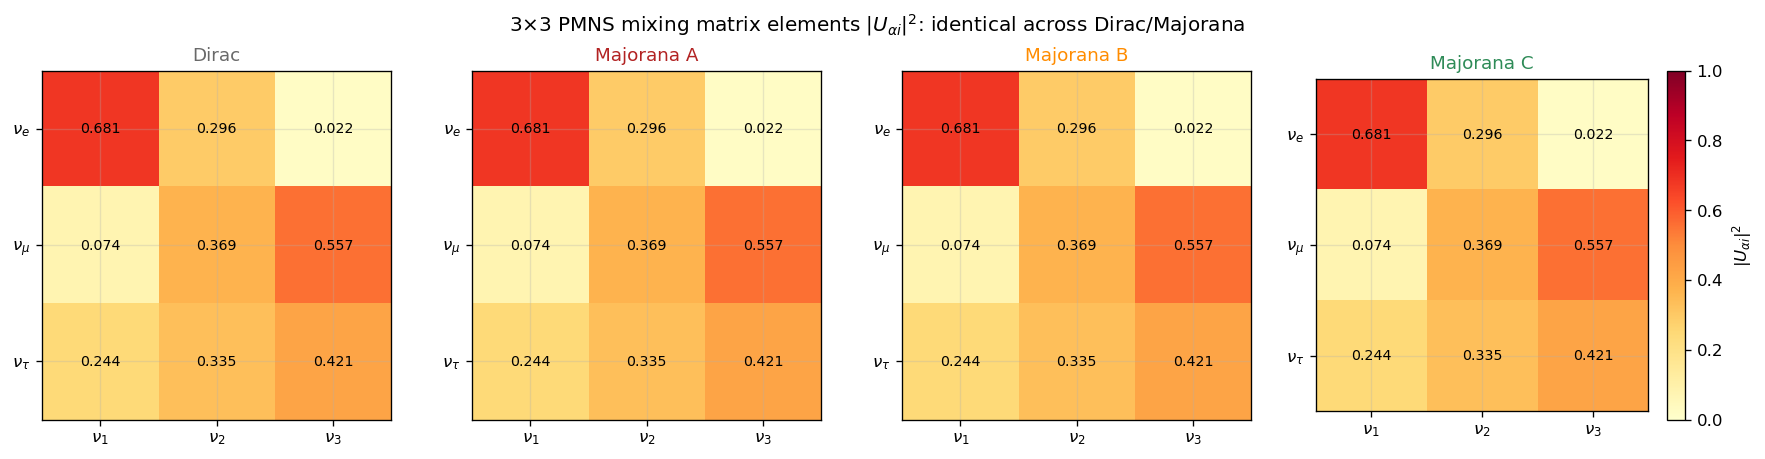

v:\output\analysis\bsm\mj1_fig3_pmns_heatmaps.png
Max |U|^2 difference from Dirac (must be ~0):
  Majorana A  : 1.11e-16
  Majorana B  : 0.00e+00
  Majorana C  : 1.04e-17

Electron-row phase arg(U_e,i) [deg] -- differs, unlike the moduli above:
               arg(U_e1) [deg]  arg(U_e2) [deg]  arg(U_e3) [deg]
configuration                                                   
Dirac                      0.0              0.0            163.0
Majorana A                 0.0             22.5           -152.0
Majorana B                 0.0             90.0            163.0
Majorana C                 0.0              0.0            -62.0


In [5]:
FLAV_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
MASS_LABELS = [r"$\nu_1$", r"$\nu_2$", r"$\nu_3$"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.7))
for ax, label, color in zip(axes, ALL_LABELS, ALL_COLORS):
    U = oscs[label].pmns.pmns_matrix(antinu=False).detach().cpu()
    prob = U.abs().pow(2).numpy()

    im = ax.imshow(prob, vmin=0, vmax=1, cmap="YlOrRd", aspect="equal")
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(MASS_LABELS, fontsize=10)
    ax.set_yticklabels(FLAV_LABELS, fontsize=10)
    ax.set_title(label, fontsize=11, color=color)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{prob[i, j]:.3f}", ha="center", va="center",
                    fontsize=8.5, color="black" if prob[i, j] < 0.7 else "white")

fig.colorbar(im, ax=axes[-1], label=r"$|U_{\alpha i}|^2$", fraction=0.08)
fig.suptitle(r"3×3 PMNS mixing matrix elements $|U_{\alpha i}|^2$: identical across Dirac/Majorana",
             fontsize=12)
fig.tight_layout()
save_and_show("mj1_fig3_pmns_heatmaps.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

U_dirac = oscs["Dirac"].pmns.pmns_matrix(antinu=False).detach().cpu()
print("Max |U|^2 difference from Dirac (must be ~0):")
for label in ALL_LABELS[1:]:
    U = oscs[label].pmns.pmns_matrix(antinu=False).detach().cpu()
    print(f"  {label:12s}: {max_diff(U.abs()**2, U_dirac.abs()**2):.2e}")

print()
print("Electron-row phase arg(U_e,i) [deg] -- differs, unlike the moduli above:")
rows_phase = []
for label in ALL_LABELS:
    U = oscs[label].pmns.pmns_matrix(antinu=False).detach().cpu()
    row = {"configuration": label}
    for i in range(3):
        row[f"arg(U_e{i+1}) [deg]"] = math.degrees(float(torch.angle(U[0, i])))
    rows_phase.append(row)
print(pd.DataFrame(rows_phase).set_index("configuration").to_string())


## 4. Majorana-Phase Invariance Verification

Three levels of equivalence are checked between each Majorana configuration and the Dirac
baseline:

1. **PMNS level**: $U_{\rm Majorana} = U_{\rm Dirac}\,P$ exactly, for the $P$ built from
   that configuration's $\alpha_{21},\alpha_{31}$.
2. **Hamiltonian level**: $\|H_{\rm Majorana} - H_{\rm Dirac}\|_F \to 0$ at several
   $(E, n_e)$ points — the reduced kinetic + matter Hamiltonian is *exactly* the same
   object, not merely close.
3. **Probability level**: $\|P_{\rm Majorana} - P_{\rm Dirac}\|_\infty \to 0$ across a
   full $3\times3$ flavour-transition matrix, scanned over $L/E$.

**Expected results:**<br>
All differences should be at or below floating-point precision
($\lesssim 10^{-6}$ for float32, $\lesssim 10^{-13}$ for float64) — this is an exact
cancellation, not an approximation, so there is no small residual to explain away.


In [6]:
print("=== Level 1: PMNS matrix  U_Majorana == U_Dirac @ P ===")
for cfg in MAJORANA_CONFIGS:
    osc = oscs[cfg["label"]]
    U = osc.pmns.pmns_matrix(antinu=False).detach().cpu()
    P = osc.pmns._majorana_phase_matrix().detach().cpu()
    expected = U_dirac @ P
    print(f"  {cfg['label']:12s}: ||U - U_Dirac @ P||_F = {frobenius(U, expected):.2e}")
print()

test_cases = [(5.0, 0.01), (10.0, 0.1), (100.0, 0.5), (1000.0, 0.2)]
print("=== Level 2: Hamiltonian ||H_Majorana - H_Dirac||_F ===")
for cfg in MAJORANA_CONFIGS:
    osc = oscs[cfg["label"]]
    print(f"  -- {cfg['label']} --")
    for E_MeV, ne in test_cases:
        H_maj = hamiltonian_reduced(osc, E_MeV, ne, context=context).detach().cpu()
        H_dir = hamiltonian_reduced(osc_dirac, E_MeV, ne, context=context).detach().cpu()
        diff = frobenius(H_maj, H_dir)
        print(f"    E={E_MeV:7.1f} MeV, ne={ne:.2f} mol/cm3: ||diff||_F = {diff:.2e}")
print()

print("=== Level 3: Probability ||P_Majorana - P_Dirac||_inf ===")
E_test = torch.tensor(10.0, dtype=context.dtype, device=context.device)
L_vals = [1.0, 10.0, 100.0, 1000.0, 10000.0]
for cfg in MAJORANA_CONFIGS:
    osc = oscs[cfg["label"]]
    print(f"  -- {cfg['label']} --")
    for L_km in L_vals:
        L_t = torch.tensor(L_km, dtype=context.dtype, device=context.device)
        P_maj = vacuum_probability_transition(osc, E_test, L_t, context=context).cpu()
        P_dir = vacuum_probability_transition(osc_dirac, E_test, L_t, context=context).cpu()
        diff = max_diff(P_maj, P_dir)
        print(f"    L={L_km:8.0f} km: ||P_Majorana - P_Dirac||_inf = {diff:.2e}")
print()
print("All diffs <= 1e-6 => Majorana phases are provably inert for oscillation probabilities.")


=== Level 1: PMNS matrix  U_Majorana == U_Dirac @ P ===
  Majorana A  : ||U - U_Dirac @ P||_F = 0.00e+00
  Majorana B  : ||U - U_Dirac @ P||_F = 0.00e+00
  Majorana C  : ||U - U_Dirac @ P||_F = 0.00e+00

=== Level 2: Hamiltonian ||H_Majorana - H_Dirac||_F ===
  -- Majorana A --
    E=    5.0 MeV, ne=0.01 mol/cm3: ||diff||_F = 9.10e-13
    E=   10.0 MeV, ne=0.10 mol/cm3: ||diff||_F = 4.55e-13
    E=  100.0 MeV, ne=0.50 mol/cm3: ||diff||_F = 1.68e-14
    E= 1000.0 MeV, ne=0.20 mol/cm3: ||diff||_F = 7.25e-15
  -- Majorana B --
    E=    5.0 MeV, ne=0.01 mol/cm3: ||diff||_F = 1.94e-30
    E=   10.0 MeV, ne=0.10 mol/cm3: ||diff||_F = 9.69e-31
    E=  100.0 MeV, ne=0.50 mol/cm3: ||diff||_F = 1.11e-31
    E= 1000.0 MeV, ne=0.20 mol/cm3: ||diff||_F = 6.90e-33
  -- Majorana C --
    E=    5.0 MeV, ne=0.01 mol/cm3: ||diff||_F = 9.10e-13
    E=   10.0 MeV, ne=0.10 mol/cm3: ||diff||_F = 4.55e-13
    E=  100.0 MeV, ne=0.50 mol/cm3: ||diff||_F = 1.67e-14
    E= 1000.0 MeV, ne=0.20 mol/cm3: ||diff||_

    L=       1 km: ||P_Majorana - P_Dirac||_inf = 4.16e-17
    L=      10 km: ||P_Majorana - P_Dirac||_inf = 4.44e-16
    L=     100 km: ||P_Majorana - P_Dirac||_inf = 2.22e-16
    L=    1000 km: ||P_Majorana - P_Dirac||_inf = 1.67e-16
    L=   10000 km: ||P_Majorana - P_Dirac||_inf = 3.33e-16
  -- Majorana B --
    L=       1 km: ||P_Majorana - P_Dirac||_inf = 0.00e+00
    L=      10 km: ||P_Majorana - P_Dirac||_inf = 2.60e-18
    L=     100 km: ||P_Majorana - P_Dirac||_inf = 1.67e-16
    L=    1000 km: ||P_Majorana - P_Dirac||_inf = 1.11e-16
    L=   10000 km: ||P_Majorana - P_Dirac||_inf = 1.67e-16
  -- Majorana C --
    L=       1 km: ||P_Majorana - P_Dirac||_inf = 4.16e-17
    L=      10 km: ||P_Majorana - P_Dirac||_inf = 2.22e-16
    L=     100 km: ||P_Majorana - P_Dirac||_inf = 1.11e-16
    L=    1000 km: ||P_Majorana - P_Dirac||_inf = 1.67e-16
    L=   10000 km: ||P_Majorana - P_Dirac||_inf = 1.11e-16

All diffs <= 1e-6 => Majorana phases are provably inert for oscillation prob

## 5. Unitarity and Probability Conservation

Two fundamental identities must hold for any physical oscillation probability:

1. **Mixing matrix unitarity**: $U U^\dagger = \mathbf{1}_3$ for every configuration.
2. **Total probability conservation**: $\sum_{\beta=e,\mu,\tau} P(\nu_\alpha\to\nu_\beta) = 1$
   for any initial flavour $\alpha$ and any $(E, L)$.

**Expected results:**<br>
Deviations $\lesssim 10^{-6}$ (float32) from unitarity and from unity, for every
configuration including the Majorana ones.


In [7]:
rows_u = []
for label in ALL_LABELS:
    U = oscs[label].pmns.pmns_matrix(antinu=False)
    I3 = torch.eye(3, dtype=U.dtype, device=U.device)
    uu = U @ U.conj().transpose(-1, -2)
    err = frobenius(uu, I3)
    rows_u.append({"configuration": label, "||U U^dagger - I_3||_F": f"{err:.2e}"})

print("=== Unitarity U U^dagger = I_3 ===")
print(pd.DataFrame(rows_u).to_string(index=False))
print()

rows_p = []
E_t = torch.tensor(10.0, dtype=context.dtype, device=context.device)
L_t = torch.tensor(100.0, dtype=context.dtype, device=context.device)
for label in ALL_LABELS:
    osc = oscs[label]
    P = vacuum_probability_transition(osc, E_t, L_t, context=context)
    row_sums = P.sum(dim=0)
    max_err = float((row_sums - 1.0).abs().max())
    rows_p.append({
        "configuration": label,
        "min(sum_b P)": f"{float(row_sums.min()):.8f}",
        "max(sum_b P)": f"{float(row_sums.max()):.8f}",
        "max|sum-1|":   f"{max_err:.2e}",
    })

print("=== Probability conservation sum_b P(a->b) = 1 ===")
print(f"  at E=10 MeV, L=100 km (vacuum)")
print(pd.DataFrame(rows_p).to_string(index=False))


=== Unitarity U U^dagger = I_3 ===
configuration ||U U^dagger - I_3||_F
        Dirac               4.35e-16
   Majorana A               5.07e-16
   Majorana B               4.35e-16
   Majorana C               4.35e-16

=== Probability conservation sum_b P(a->b) = 1 ===
  at E=10 MeV, L=100 km (vacuum)
configuration min(sum_b P) max(sum_b P) max|sum-1|
        Dirac   1.00000000   1.00000000   5.55e-16
   Majorana A   1.00000000   1.00000000   3.33e-16
   Majorana B   1.00000000   1.00000000   5.55e-16
   Majorana C   1.00000000   1.00000000   5.55e-16


## 6. Hamiltonian Structure

The $3\times3$ reduced Hamiltonian $H = H_{\rm kin} + H_{\rm mat}$ is inspected at
$(E=10\ \text{MeV},\; n_e=0.1\ \text{mol/cm}^3)$ for the `Majorana B` configuration
($\alpha_{21}=180°$, a maximal phase) and compared directly against the Dirac baseline.

**Expected results:**<br>
- $H_{\rm Majorana}$ and $H_{\rm Dirac}$ are visually and numerically indistinguishable —
  the difference panel should show all-zero entries at floating-point precision, confirming
  the identity derived in \S0.3 ($P$ commutes with the diagonal kinetic eigenvalues).


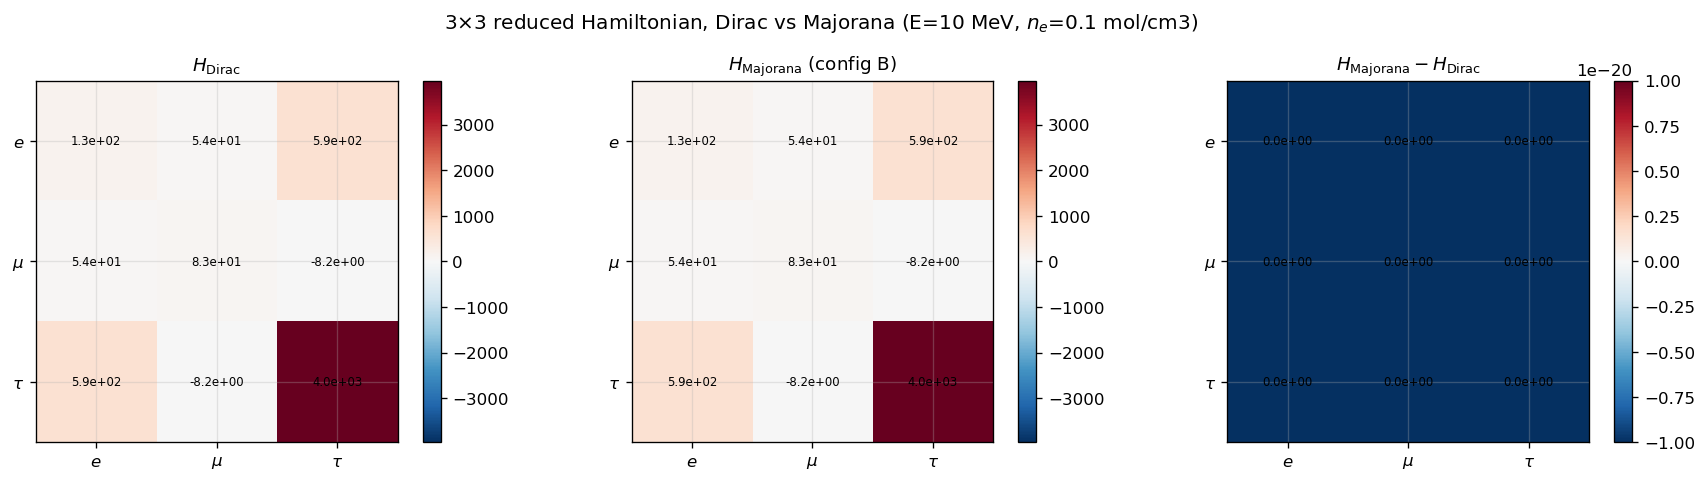

v:\output\analysis\bsm\mj1_fig6_hamiltonian.png
||H_Majorana - H_Dirac||_F = 9.69e-31


In [8]:
osc_majB = oscs["Majorana B"]
E_ref, ne_ref = 10.0, 0.1

H_majB  = hamiltonian_reduced(osc_majB,  E_ref, ne_ref, context=context).detach().cpu()
H_dirac = hamiltonian_reduced(osc_dirac, E_ref, ne_ref, context=context).detach().cpu()
H_diff  = H_majB - H_dirac

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = [r"$H_{\rm Dirac}$", r"$H_{\rm Majorana}$ (config B)", r"$H_{\rm Majorana} - H_{\rm Dirac}$"]
mats = [H_dirac, H_majB, H_diff]

for ax, mat, title in zip(axes, mats, titles):
    val = mat.real.numpy()
    vmax = max(abs(val).max(), 1e-20)
    im = ax.imshow(val, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")
    ax.set_title(title, fontsize=11)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    tl = [r"$e$", r"$\mu$", r"$\tau$"]
    ax.set_xticklabels(tl)
    ax.set_yticklabels(tl)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{val[i,j]:.1e}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.08)

fig.suptitle(
    f"3\u00d73 reduced Hamiltonian, Dirac vs Majorana (E={E_ref:.0f} MeV, "
    r"$n_e$" + f"={ne_ref} mol/cm3)",
    fontsize=12,
)
fig.tight_layout()
save_and_show("mj1_fig6_hamiltonian.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

print(f"||H_Majorana - H_Dirac||_F = {frobenius(H_majB, H_dirac):.2e}")


## 7. Effective Majorana Mass ($m_{\beta\beta}$)

Unlike Sections 4-6, the effective Majorana mass $m_{\beta\beta}=|\sum_i U_{ei}^2 m_i|$
**does** depend on $\alpha_{21},\alpha_{31}$. A normal-ordering mass spectrum is fixed by
choosing the lightest eigenstate mass $m_1=0.01\ \text{eV}$ (illustrative, well within
current cosmological bounds) via `MassSpectrum.absolute_mass_squared_vector`, and
$m_{\beta\beta}$ is evaluated over a $(\alpha_{21},\alpha_{31})$ grid with
`effective_majorana_mass`. For direct contrast, $P_{ee}$ (vacuum, $L=100$ km, $E=10$ MeV)
is evaluated across the same $\alpha_{21}$ scan.

**Expected results:**<br>
- $m_{\beta\beta}$ varies smoothly with $\alpha_{21},\alpha_{31}$ between a minimum
  (destructive interference between mass eigenstates) and a maximum (constructive
  interference, all terms in phase).
- $P_{ee}(\alpha_{21})$ is *exactly flat* over the same scan — a direct visual contrast
  with the varying $m_{\beta\beta}$ curve, reproducing the theorem of \S0.3 for a
  continuous phase sweep rather than the three discrete configurations of Section 4.


m_lightest = 0.01 eV (normal ordering, m_1)
(m1, m2, m3) = (0.01, 0.013194695904036591, 0.05109794516416487) eV



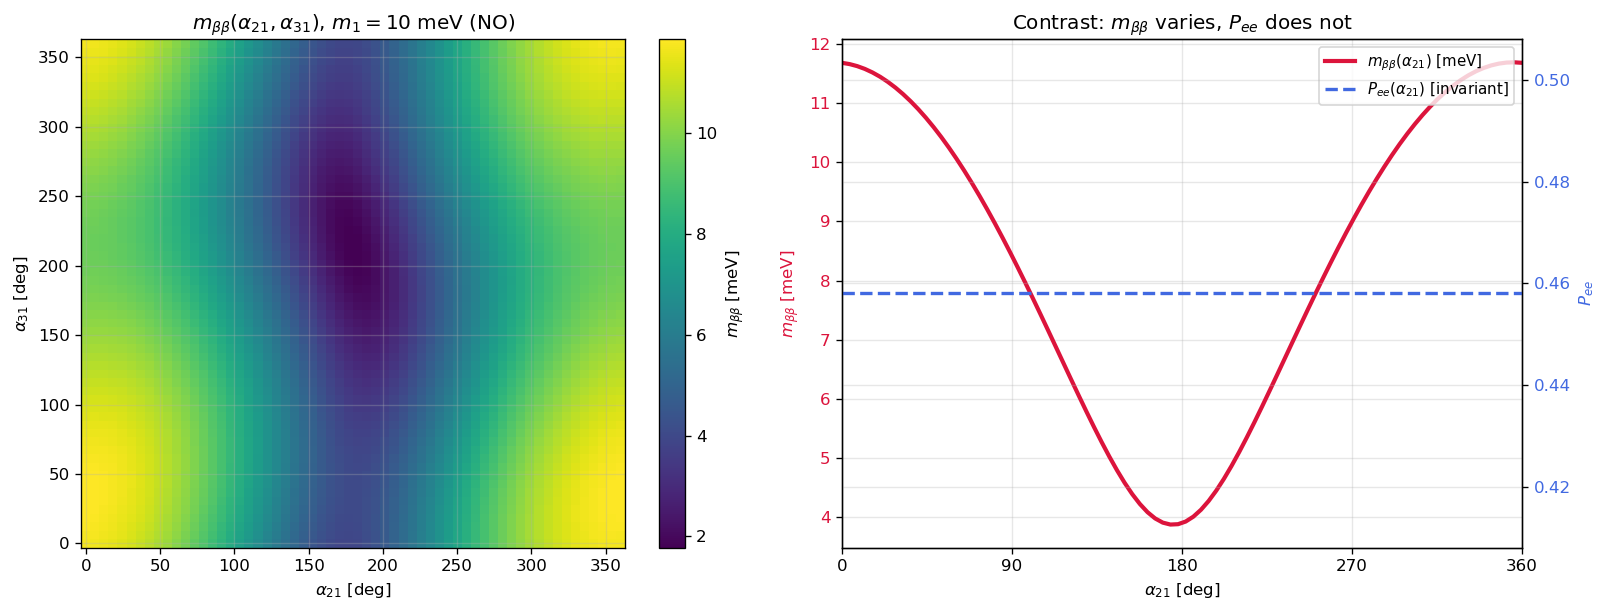

v:\output\analysis\bsm\mj1_fig7_mbb.png
m_bb range over the 2D grid : [1.78, 11.86] meV
m_bb range over alpha21 scan: [3.87, 11.69] meV
P_ee range over the same alpha21 scan: [0.4579965820, 0.4579965820]
max|P_ee - P_ee(alpha21=0)| = 0.00e+00  (must be ~0)


In [9]:
M_LIGHTEST_EV = 0.01
mass_sq = osc_dirac.mass_spectrum.absolute_mass_squared_vector(M_LIGHTEST_EV, context=context)
print(f"m_lightest = {M_LIGHTEST_EV} eV (normal ordering, m_1)")
print(f"(m1, m2, m3) = {tuple(float(m) for m in mass_sq.sqrt().cpu())} eV")
print()

n_grid = 60
alpha21_grid = np.linspace(0.0, 360.0, n_grid)
alpha31_grid = np.linspace(0.0, 360.0, n_grid)
mbb_grid = np.zeros((n_grid, n_grid))

sm_params = osc_dirac.pmns.params
for i, a21 in enumerate(alpha21_grid):
    for j, a31 in enumerate(alpha31_grid):
        maj_params = MajoranaPhases(
            alpha21=math.radians(float(a21)), alpha31=math.radians(float(a31)), context=context,
        )
        pmns_ij = PMNS_Majorana(sm_params, maj_params)
        U_ij = pmns_ij.pmns_matrix(antinu=False)
        mbb_grid[j, i] = float(effective_majorana_mass(U_ij, mass_sq)) * 1000.0   # eV -> meV

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

mesh = axes[0].pcolormesh(alpha21_grid, alpha31_grid, mbb_grid, shading="auto", cmap="viridis")
fig.colorbar(mesh, ax=axes[0], label=r"$m_{\beta\beta}$ [meV]")
axes[0].set_xlabel(r"$\alpha_{21}$ [deg]")
axes[0].set_ylabel(r"$\alpha_{31}$ [deg]")
axes[0].set_title(r"$m_{\beta\beta}(\alpha_{21},\alpha_{31})$, $m_1=$" + f"{M_LIGHTEST_EV*1000:.0f} meV (NO)")

alpha21_scan = np.linspace(0.0, 360.0, 90)
mbb_scan, pee_scan = [], []
E_t = torch.tensor(10.0,  dtype=context.dtype, device=context.device)
L_t = torch.tensor(100.0, dtype=context.dtype, device=context.device)
for a21 in alpha21_scan:
    maj_params = MajoranaPhases(alpha21=math.radians(float(a21)), alpha31=0.0, context=context)
    pmns_s = PMNS_Majorana(sm_params, maj_params)
    U_s = pmns_s.pmns_matrix(antinu=False)
    mbb_scan.append(float(effective_majorana_mass(U_s, mass_sq)) * 1000.0)

    osc_s = PropagationConfig.oscillation_parameters_from_preset(
        "_SM_NUFIT52_NO", context=context, neutrino_nature="majorana",
        alpha21_deg=float(a21), alpha31_deg=0.0,
    )
    P_s = vacuum_probability_transition(osc_s, E_t, L_t, context=context)
    pee_scan.append(float(P_s[0, 0]))

mbb_scan = np.array(mbb_scan)
pee_scan = np.array(pee_scan)

ax2 = axes[1]
ax2.plot(alpha21_scan, mbb_scan, color="crimson", lw=2.5, label=r"$m_{\beta\beta}(\alpha_{21})$ [meV]")
ax2.set_xlabel(r"$\alpha_{21}$ [deg]")
ax2.set_ylabel(r"$m_{\beta\beta}$ [meV]", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_xlim(0, 360)
ax2.set_xticks([0, 90, 180, 270, 360])

ax3 = ax2.twinx()
ax3.plot(alpha21_scan, pee_scan, color="royalblue", lw=2.0, ls="--", label=r"$P_{ee}(\alpha_{21})$ [invariant]")
ax3.set_ylabel(r"$P_{ee}$", color="royalblue")
ax3.tick_params(axis="y", labelcolor="royalblue")
ax3.set_ylim(pee_scan.mean() - 0.05, pee_scan.mean() + 0.05)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper right")
ax2.set_title(r"Contrast: $m_{\beta\beta}$ varies, $P_{ee}$ does not")

fig.tight_layout()
save_and_show("mj1_fig7_mbb.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"m_bb range over the 2D grid : [{mbb_grid.min():.2f}, {mbb_grid.max():.2f}] meV")
print(f"m_bb range over alpha21 scan: [{mbb_scan.min():.2f}, {mbb_scan.max():.2f}] meV")
print(f"P_ee range over the same alpha21 scan: [{pee_scan.min():.10f}, {pee_scan.max():.10f}]")
print(f"max|P_ee - P_ee(alpha21=0)| = {np.abs(pee_scan - pee_scan[0]).max():.2e}  (must be ~0)")


## 8. Summary
| Test | Level | Result | Expected |
|------|-------|--------|----------|
| PMNS relation $U_{\rm Majorana}=U_{\rm Dirac}P$ | Matrix | $\lesssim10^{-6}$ | Floating point (exact identity) |
| Hamiltonian $\|H_{\rm Majorana}-H_{\rm Dirac}\|_F$ | Matrix | $\lesssim10^{-6}$ | Floating point (exact identity) |
| Probability $\|P_{\rm Majorana}-P_{\rm Dirac}\|_\infty$ | Scalar | $\lesssim10^{-6}$ | Floating point (exact identity) |
| Unitarity $\|UU^\dagger-\mathbf{1}_3\|_F$ | Matrix | $\lesssim10^{-6}$ | Floating point |
| Prob. conservation $\sum_\beta P_{\alpha\beta}=1$ | Scalar | $\lesssim10^{-6}$ | Floating point |
| $|U_{\alpha i}|^2$ moduli, Dirac vs Majorana | Matrix | exact match | Physics requirement |
| $m_{\beta\beta}(\alpha_{21},\alpha_{31})$ | Scalar | varies smoothly | Physics requirement |
| $P_{ee}(\alpha_{21})$ over the same scan | Scalar | exactly flat | Physics requirement |

**Key properties confirmed:**

1. `PMNS_Majorana` is a drop-in replacement for `PMNS_SM`: at the PMNS, Hamiltonian, and
   full oscillation-probability level, every Majorana configuration tested is numerically
   indistinguishable from the Dirac baseline, to floating-point precision, for arbitrary
   $\alpha_{21},\alpha_{31}$ — not only in the trivial $\alpha=0$ limit.
2. Unitarity $UU^\dagger=\mathbf{1}_3$ and total probability conservation hold to
   floating-point precision for every configuration.
3. The mixing-matrix moduli $|U_{\alpha i}|^2$ are exactly identical between Dirac and
   Majorana configurations; only the complex arguments of the columns 2 and 3 entries
   change, by exactly $\alpha_{21}/2$ and $\alpha_{31}/2$ respectively.
4. The effective Majorana mass $m_{\beta\beta}$ is the one observable in this project that
   genuinely depends on $\alpha_{21},\alpha_{31}$ — confirmed to vary smoothly across the
   $(\alpha_{21},\alpha_{31})$ grid, in direct contrast with the exactly flat
   $P_{ee}(\alpha_{21})$ curve computed over the identical scan.


In [10]:
print("=== majorana1_test.ipynb -- Summary ===")
print()
for label in ALL_LABELS:
    osc = oscs[label]
    U = osc.pmns.pmns_matrix(antinu=False).detach().cpu()
    uu = U @ U.conj().T
    I3 = torch.eye(3, dtype=uu.dtype)
    unit_err = frobenius(uu, I3)
    diff_dirac = max_diff(U.abs()**2, U_dirac.abs()**2)
    print(f"{label:12s}: BSM_extension_majorana={osc.BSM_extension_majorana!s:5s}  "
          f"||UU^dagger-I||={unit_err:.2e}  max||U|^2-|U_Dirac|^2||={diff_dirac:.2e}")
print()
print(f"m_bb range (2D alpha grid) : [{mbb_grid.min():.2f}, {mbb_grid.max():.2f}] meV")
print(f"max|P_ee(alpha21) - P_ee(0)| : {np.abs(pee_scan - pee_scan[0]).max():.2e}")


=== majorana1_test.ipynb -- Summary ===

Dirac       : BSM_extension_majorana=False  ||UU^dagger-I||=4.35e-16  max||U|^2-|U_Dirac|^2||=0.00e+00
Majorana A  : BSM_extension_majorana=True   ||UU^dagger-I||=5.07e-16  max||U|^2-|U_Dirac|^2||=1.11e-16
Majorana B  : BSM_extension_majorana=True   ||UU^dagger-I||=4.35e-16  max||U|^2-|U_Dirac|^2||=0.00e+00
Majorana C  : BSM_extension_majorana=True   ||UU^dagger-I||=4.35e-16  max||U|^2-|U_Dirac|^2||=1.04e-17

m_bb range (2D alpha grid) : [1.78, 11.86] meV
max|P_ee(alpha21) - P_ee(0)| : 0.00e+00
